# Projeto de Machine Learning — Risco de Crédito

Este notebook apresenta o desenvolvimento de um pipeline de Machine Learning para previsão de risco de crédito.

A base escolhida foi a **Opção A — Risco de Crédito**, cujo objetivo é prever se um cliente poderá se tornar inadimplente ou se pagará o empréstimo em dia.

A variável alvo do projeto é `loan_status`, onde:

- `0` representa cliente pagador;
- `1` representa cliente inadimplente.



## Etapas do projeto

O projeto será organizado nas seguintes fases:

1. **Análise Exploratória de Dados (EDA)**
2. **Tratamento e Limpeza dos Dados**
3. **Feature Engineering**
4. **Separação, Balanceamento e Escalonamento Seguro**
5. **Modelagem com KNN e Árvore de Decisão**
6. **Avaliação Final e Veredito de Negócio**

Além do código, cada etapa contém explicações em Markdown para deixar o notebook adequado a uma entrega acadêmica.

## 0. Importação das bibliotecas

Nesta etapa, importamos as bibliotecas utilizadas para manipulação dos dados, visualização, preparação, balanceamento, modelagem e avaliação dos modelos.

In [1]:
# Bibliotecas principais para manipulação e análise de dados
import pandas as pd
import numpy as np

# Bibliotecas para visualização de dados
import matplotlib.pyplot as plt
import seaborn as sns

# Biblioteca para trabalhar com caminhos de arquivos
from pathlib import Path

# Configuração para exibir mais colunas no notebook
pd.set_option("display.max_columns", None)

# Configuração visual padrão dos gráficos
sns.set_theme(style="whitegrid")

Matplotlib is building the font cache; this may take a moment.


In [2]:
# Definindo o caminho da base de dados
# O código abaixo funciona tanto se o notebook estiver sendo executado da raiz do projeto
# quanto se estiver sendo executado diretamente da pasta notebooks.

base_dir = Path.cwd()

if (base_dir / "data" / "credit_risk_dataset.csv").exists():
    caminho_csv = base_dir / "data" / "credit_risk_dataset.csv"
else:
    caminho_csv = base_dir.parent / "data" / "credit_risk_dataset.csv"

# Carregando a base de dados
df = pd.read_csv(caminho_csv)

# Exibindo as primeiras linhas da base
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [3]:
# Verificando o tamanho da base de dados
linhas, colunas = df.shape

print(f"A base possui {linhas} linhas e {colunas} colunas.")

A base possui 32581 linhas e 12 colunas.


In [4]:
# Visualizando informações gerais da base:
# - nome das colunas
# - quantidade de valores não nulos
# - tipo de dado de cada variável

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB


In [5]:
# Listando todas as colunas disponíveis na base
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='str')

## 1.1 Carregamento inicial da base

Nesta etapa foi realizada a importação das principais bibliotecas utilizadas no projeto e o carregamento da base `credit_risk_dataset.csv`.

Também foi feita uma verificação inicial do tamanho da base, dos tipos de dados e das primeiras linhas do conjunto de dados. Essa análise inicial é importante para compreender a estrutura do problema antes de aplicar qualquer tratamento, transformação ou modelo de Machine Learning.

## 1.2 Análise descritiva inicial

Nesta etapa será realizada uma análise descritiva da base de dados, com o objetivo de compreender melhor a estrutura das variáveis, identificar valores ausentes, verificar duplicidades e analisar a distribuição da variável alvo `loan_status`.

Essa etapa é importante porque decisões de limpeza, tratamento de nulos, tratamento de outliers e balanceamento dependem diretamente do comportamento inicial dos dados.

In [6]:
# Estatísticas descritivas das variáveis numéricas
# O .T é utilizado apenas para transpor a tabela e facilitar a leitura no notebook.

df.describe().T

,count,mean,std,min,25%,50%,75%,max
person_age,32581.0,27.734600,6.348078,20.00,23.00,26.00,30.00,144.00
person_income,32581.0,66074.848470,61983.119168,4000.00,38500.00,55000.00,79200.00,6000000.00
person_emp_length,31686.0,4.789686,4.142630,0.00,2.00,4.00,7.00,123.00
loan_amnt,32581.0,9589.371106,6322.086646,500.00,5000.00,8000.00,12200.00,35000.00
loan_int_rate,29465.0,11.011695,3.240459,5.42,7.90,10.99,13.47,23.22
loan_status,32581.0,0.218164,0.413006,0.00,0.00,0.00,0.00,1.00
loan_percent_income,32581.0,0.170203,0.106782,0.00,0.09,0.15,0.23,0.83
cb_person_cred_hist_length,32581.0,5.804211,4.055001,2.00,3.00,4.00,8.00,30.00


In [7]:
# Estatísticas descritivas das variáveis categóricas
# include="object" seleciona apenas colunas textuais/categóricas.

df.describe(include="object").T

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_15356\3442359427.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object").T


,count,unique,top,freq
person_home_ownership,32581,4,RENT,16446
loan_intent,32581,6,EDUCATION,6453
loan_grade,32581,7,A,10777
cb_person_default_on_file,32581,2,N,26836


In [8]:
# Verificando a quantidade e o percentual de valores nulos em cada coluna

nulos = pd.DataFrame({
    "quantidade_nulos": df.isnull().sum(),
    "percentual_nulos": (df.isnull().mean() * 100).round(2)
})

nulos = nulos[nulos["quantidade_nulos"] > 0].sort_values(
    by="quantidade_nulos",
    ascending=False
)

nulos

,quantidade_nulos,percentual_nulos
loan_int_rate,3116,9.56
person_emp_length,895,2.75


In [9]:
# Verificando a quantidade de linhas duplicadas na base

quantidade_duplicadas = df.duplicated().sum()

print(f"A base possui {quantidade_duplicadas} linhas duplicadas.")

A base possui 165 linhas duplicadas.


In [10]:
# Verificando a distribuição absoluta e percentual da variável alvo loan_status

distribuicao_alvo = pd.DataFrame({
    "quantidade": df["loan_status"].value_counts(),
    "percentual": (df["loan_status"].value_counts(normalize=True) * 100).round(2)
})

distribuicao_alvo.index = ["Pagador - Classe 0", "Inadimplente - Classe 1"]

distribuicao_alvo

,quantidade,percentual
Pagador - Classe 0,25473,78.18
Inadimplente - Classe 1,7108,21.82


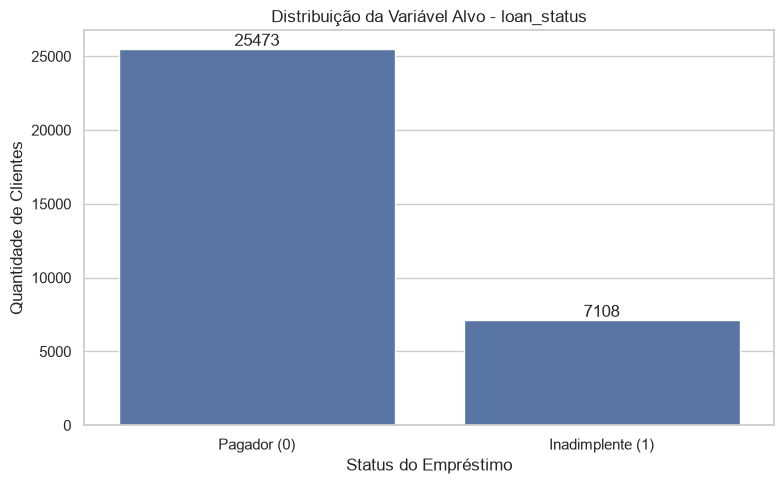

In [11]:
# Gráfico de barras para visualizar o desbalanceamento da variável alvo

plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="loan_status"
)

plt.title("Distribuição da Variável Alvo - loan_status")
plt.xlabel("Status do Empréstimo")
plt.ylabel("Quantidade de Clientes")
plt.xticks(
    ticks=[0, 1],
    labels=["Pagador (0)", "Inadimplente (1)"]
)

# Adicionando os valores acima das barras
for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

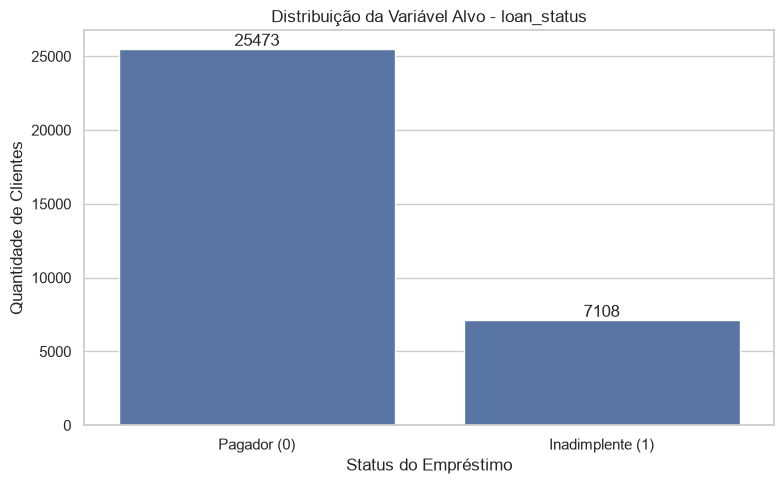

In [12]:
# Salvando o gráfico da variável alvo para uso posterior no README.md

caminho_grafico_alvo = Path("../imagens/graficos_eda/distribuicao_variavel_alvo.png")

plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="loan_status"
)

plt.title("Distribuição da Variável Alvo - loan_status")
plt.xlabel("Status do Empréstimo")
plt.ylabel("Quantidade de Clientes")
plt.xticks(
    ticks=[0, 1],
    labels=["Pagador (0)", "Inadimplente (1)"]
)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.savefig(caminho_grafico_alvo, dpi=300, bbox_inches="tight")
plt.show()

## 1.3 Interpretação inicial da análise descritiva

A análise descritiva inicial mostrou que a base possui variáveis numéricas e categóricas relacionadas ao perfil do cliente, características do empréstimo e histórico de crédito.

Foram identificados valores ausentes em variáveis importantes, como `person_emp_length` e `loan_int_rate`, que precisarão ser tratados na etapa de preparação dos dados. Também foram encontradas linhas duplicadas, que serão removidas na fase de limpeza para evitar redundância no treinamento dos modelos.

A distribuição da variável alvo `loan_status` indica desbalanceamento entre as classes, com maior quantidade de clientes pagadores em comparação aos inadimplentes. Isso mostra que será necessário aplicar uma técnica de balanceamento somente nos dados de treino, evitando vazamento de dados para a base de teste.

Também é possível observar indícios de valores extremos em algumas variáveis numéricas, como idade, renda e tempo de emprego. Esses pontos serão avaliados com gráficos de boxplot antes da decisão final de tratamento dos outliers.